# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Verificar que el archivo CSV tenía la estructura correcta según la consigna | "Analiza el archivo corpus_tpi2.csv y dime qué tiene mal" | La IA identificó que las columnas tenían los nombres de las variables Python (`COLUMNA_TEXTO`, `COLUMNA_GRUPO`) en lugar de los valores correctos (`texto`, `grupo_comparacion`), que `grupo_comparacion` estaba vacía (todo NaN) y que el encoding era `latin-1` en lugar de UTF-8 | Se adoptó la corrección de nombres de columna, el relleno de `grupo_comparacion` desde la columna `medio`, y la conversión a UTF-8. Fueron cambios estructurales necesarios para que el notebook pudiera ejecutarse | No se alteró ninguna columna de contenido (`texto`, `medio`, etc.) porque los datos en sí eran correctos |
| Procesamiento con spaCy | Entender qué hace cada función del bloque de procesamiento lingüístico | "Explicame qué hace `nlp.pipe()`, `token.is_stop` y la función `normalizar_lemma`" | Explicó que `nlp.pipe()` procesa lotes de texto de forma eficiente, que `is_stop` filtra palabras funcionales sin contenido semántico y que lematizar normaliza las formas flexionadas a su raíz común | Se incorporaron estas explicaciones como comentarios de código en las celdas correspondientes | No se modificó el código base porque la consigna prohíbe alterar la estructura |
| Representaciones sparse | Clarificar la diferencia entre BoW y TF-IDF aplicada al corpus propio | "¿Por qué `latamgpt` y `china` no aparecen entre los términos más frecuentes globales pero sí en el top de TF-IDF?" | Explicó que BoW cuenta frecuencias brutas y que TF-IDF penaliza los términos compartidos entre grupos y premia los exclusivos. Un término puede ser poco frecuente en términos absolutos pero muy diagnóstico de un grupo | Esta distinción se conservó íntegramente en la sección de escritura interpretativa porque clarifica el hallazgo central del análisis | Se descartó la sugerencia de filtrar los términos en inglés presentes en Anfibia, porque forman parte del estilo académico genuino de ese corpus |
| Visualización | Interpretar el heatmap de TF-IDF generado por el notebook | "¿Cómo leer el mapa de calor de términos distintivos?" | Señaló que las celdas con color más intenso indican mayor especificidad: términos frecuentes en un grupo y casi ausentes en el otro | Se usó esta lectura en la sección de interpretación, señalando los ejes de contraste más claros | No se cambió la paleta de colores ni el tipo de gráfico porque el resultado era legible y pertinente |
| Interpretación final | Auditar la coherencia entre los datos y la interpretación discursiva redactada | "¿El contraste que describimos entre Cenital y Anfibia está sostenido por los observables?" | Confirmó que el contraste geopolítico/económico (Cenital) vs. crítico/latinoamericano (Anfibia) está respaldado por los datos de TF-IDF y bigramas, y señaló el desbalance de extensión como límite metodológico | Se incorporó el señalamiento del desbalance en la sección de límites. La interpretación principal se mantuvo | No se adoptó una conclusión más contundente porque el corpus pequeño (10 textos) no lo justifica estadísticamente |

## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# --- Importaciones necesarias ---
from pathlib import Path  # Manejo de rutas de archivos de forma multiplataforma (Windows/Mac/Linux)
import re                 # Expresiones regulares para buscar patrones dentro de textos
from collections import Counter  # Conteo eficiente de frecuencias de elementos en una lista

import matplotlib.pyplot as plt  # Librería base para crear gráficos y figuras
import pandas as pd              # Manipulación y análisis de datos en tablas (DataFrames)
import seaborn as sns            # Visualizaciones estadísticas construidas sobre matplotlib
from IPython.display import display  # Permite mostrar tablas y objetos con formato enriquecido en el notebook
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# CountVectorizer: transforma texto en una matriz de frecuencias absolutas (Bag of Words)
# TfidfVectorizer: transforma texto en una matriz TF-IDF (frecuencia ponderada por rareza del término en el corpus)

# Configuración visual global aplicada a todos los gráficos del notebook:
# style="ticks": estilo limpio con marcas solo en los ejes
# palette="colorblind": colores accesibles para personas con daltonismo
# font_scale=1.0: tamaño de fuente estándar del notebook
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")        # Guardamos la paleta para reutilizarla si es necesario
pd.set_option("display.max_colwidth", 140)      # Muestra hasta 140 caracteres por celda (evita truncamientos prematuros)

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [2]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus antes de ejecutar el resto del notebook

RUTA_CORPUS = Path("corpus_tpi2.csv")  # Ruta al archivo del corpus (debe estar en la misma carpeta que el notebook)
FORMATO_CORPUS = "csv"   # Formato del archivo: "csv" para tablas separadas por coma, "jsonl" para JSON por línea

COLUMNA_TEXTO = "texto"              # Nombre de la columna que contiene el texto completo de cada artículo
COLUMNA_GRUPO = "grupo_comparacion"  # Columna que identifica el grupo al que pertenece cada texto (ej: "Cenital" o "Anfibia")
MODELO_SPACY = "es_core_news_sm"     # Modelo lingüístico de spaCy en español (versión pequeña, suficiente para lematización y NER)
TOP_N = 12               # Cuántos términos mostrar en las tablas de frecuencias, TF-IDF y bigramas
MIN_DF = 1               # Frecuencia mínima de documentos: un término debe aparecer en al menos 1 documento
MAX_DF = 0.95            # Frecuencia máxima: descarta términos presentes en más del 95% de los documentos (muy comunes para discriminar)
VENTANA_FRAGMENTO = 140  # Cantidad de caracteres de contexto a mostrar antes y después del término en la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")

Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [3]:
# Columnas mínimas exigidas por la consigna: si alguna falta, el corpus no es válido para el análisis
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)             # Lee el CSV y lo convierte en un DataFrame de pandas
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True) # Cada línea del archivo JSONL es un objeto JSON independiente
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    # Comparamos las columnas requeridas contra las que realmente están en el DataFrame
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    # La consigna exige entre 6 y 10 textos para asegurar un corpus analizable pero manejable
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    # Verificamos que haya exactamente dos valores únicos en la columna de comparación
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()  # .copy() evita modificar el DataFrame original en memoria
validar_corpus(df)

# Normalizamos tipos de datos para evitar errores en cálculos posteriores
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")  # errors="coerce" convierte fechas inválidas en NaT (Not a Time) en vez de fallar
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()  # Rellena nulos con "" y elimina espacios sobrantes

# Contamos palabras aproximadas usando una expresión regular:
# \b[^\W\d_]{2,}\b detecta secuencias de 2 o más caracteres alfabéticos
# excluye dígitos (\d), guiones bajos (_), símbolos y palabras muy cortas
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))

Documentos cargados: 10
Grupos detectados: ['Anfibia', 'Cenital']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,C-1,2021-01-06,Cenital,Valentin Muro,La burbuja de la inteligencia artificial,Cenital,1579
1,C-2,NaT,Cenital,Valentin Muro,"La inteligencia artificial no muestra el pasado, lo reescribe",Cenital,1465
2,C-3,NaT,Cenital,Alejandro Giuffrida,Una nueva vida no biolÃ³gica: Â¿quÃ© tan gobernados estamos por la inteligencia artificial?,Cenital,2121
3,C-4,2025-10-11,Cenital,Federico Merke,"La nueva fase de la competencia tecnolÃ³gica: chips, datos y poder",Cenital,591
4,C-5,NaT,Cenital,Agostina Mileo,La inteligencia artificial no previene la estupidez natural,Cenital,2992
5,C-6,2025-07-07,Anfibia,Ernesto Picco,Una IA latinoamericana es posible,Anfibia,4084
6,C-7,NaT,Anfibia,SofÃ­a Trejo,"Inteligencia artificial, pero Â¿a quÃ© costo?",Anfibia,3185
7,C-8,2021-01-06,Anfibia,"IvÃ¡n Meza Ruiz, SofÃ­a Trejo, Fernanda LÃ³pez",Â¿QuiÃ©n controla los sistemas de Inteligencia Artificial?,Anfibia,4665
8,C-9,2021-12-05,Anfibia,Esteban Magnani,Â¿Hacia dÃ³nde nos lleva la inteligencia artificial?,Anfibia,1237
9,C-10,2024-02-09,Anfibia,MartÃ­n Mazzini,Es lo que AI,Anfibia,2045


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


### Justificación del recorte

**¿Qué comparamos exactamente?**

Comparamos cómo dos medios digitales argentinos de periodismo de largo aliento —*Cenital* y *Anfibia*— abordan el fenómeno de la inteligencia artificial en el período 2021–2025. El corpus reúne 5 artículos de cada medio sobre IA, seleccionados por tratar la temática de forma central y sostenida (no como referencia ocasional).

**¿Por qué este corpus y no otro?**

La elección responde a tres razones. Primero, ambas publicaciones tienen perfil editorial definido y público identificable: Cenital produce periodismo de datos y análisis de coyuntura política-tecnológica; Anfibia produce periodismo narrativo y ensayo académico-cultural. Segundo, la IA es un tema que ambas cubren con suficiente densidad como para encontrar piezas comparables en extensión y tratamiento. Tercero, la diferencia de enfoque editorial es lo suficientemente marcada como para esperar contrastes discursivos observables con herramientas de text mining.

**¿Qué hace comparables a los dos grupos?**

Los hace comparables el hecho de que comparten: (a) mismo universo temático (inteligencia artificial); (b) mismo formato textual (artículo de opinión o análisis periodístico extenso); (c) mismo período temporal aproximado (2021–2025); (d) mismo idioma (español rioplatense); (e) misma plataforma de distribución (digital, acceso abierto). La diferencia radica en la posición editorial y el encuadre analítico —geopolítico vs. técnico-latinoamericano— que es precisamente lo que el análisis debe confirmar o refutar.

**¿Qué límites iniciales ya vemos en el recorte?**

- **Desbalance de extensión:** los textos de Anfibia son significativamente más largos (~3.043 palabras promedio) que los de Cenital (~1.749 palabras). Anfibia aportará más términos de forma bruta, lo que puede inflar sus frecuencias absolutas. TF-IDF mitiga parcialmente este problema al trabajar con pesos relativos.
- **Heterogeneidad de autores en Cenital:** los 5 artículos tienen 5 autores distintos, lo que introduce variación de estilo individual. En Anfibia hay mayor recurrencia de autoras/es.
- **Corpus pequeño:** 10 textos son suficientes para la consigna pero insuficientes para generalizar. Cualquier afirmación sobre "el discurso de Cenital" o "el discurso de Anfibia" debe leerse como tendencia observable en esta muestra, no como caracterización de la publicación completa.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [4]:
# Armamos una tabla resumen con métricas básicas del corpus completo.
# Esta vista rápida permite verificar el tamaño y el balance del corpus antes del análisis.
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),                                                 # Cantidad total de textos en el corpus
            int(df["num_palabras"].sum()),                           # Total de palabras en todo el corpus
            round(df["num_palabras"].mean(), 1),                     # Promedio de palabras por texto (redondeado a 1 decimal)
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],         # Nombre del primer grupo (orden alfabético)
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],         # Nombre del segundo grupo
        ],
    }
)

display(resumen_corpus)

,métrica,valor
0,documentos,10
1,palabras aproximadas,23964
2,promedio por texto,2396.4
3,grupo 1,Anfibia
4,grupo 2,Cenital


In [5]:
# Agrupamos el corpus por grupo y calculamos métricas comparativas.
# Si hay diferencias importantes de extensión, el análisis de frecuencias brutas será menos confiable.
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)       # Agrupamos las filas del DataFrame según el valor de grupo_comparacion
    .agg(
        documentos=("id", "count"),                   # Contamos cuántos textos tiene cada grupo
        palabras_totales=("num_palabras", "sum"),     # Sumamos el total de palabras de todos los textos del grupo
        promedio_palabras=("num_palabras", "mean"),   # Calculamos el promedio de palabras por texto del grupo
    )
    .reset_index()                  # Convertimos el índice de grupo en columna normal para poder usarlo en gráficos
    .sort_values(COLUMNA_GRUPO)     # Ordenamos los grupos alfabéticamente para consistencia visual
)

display(resumen_por_grupo)

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,Anfibia,5,15216,3043.2
1,Cenital,5,8748,1749.6


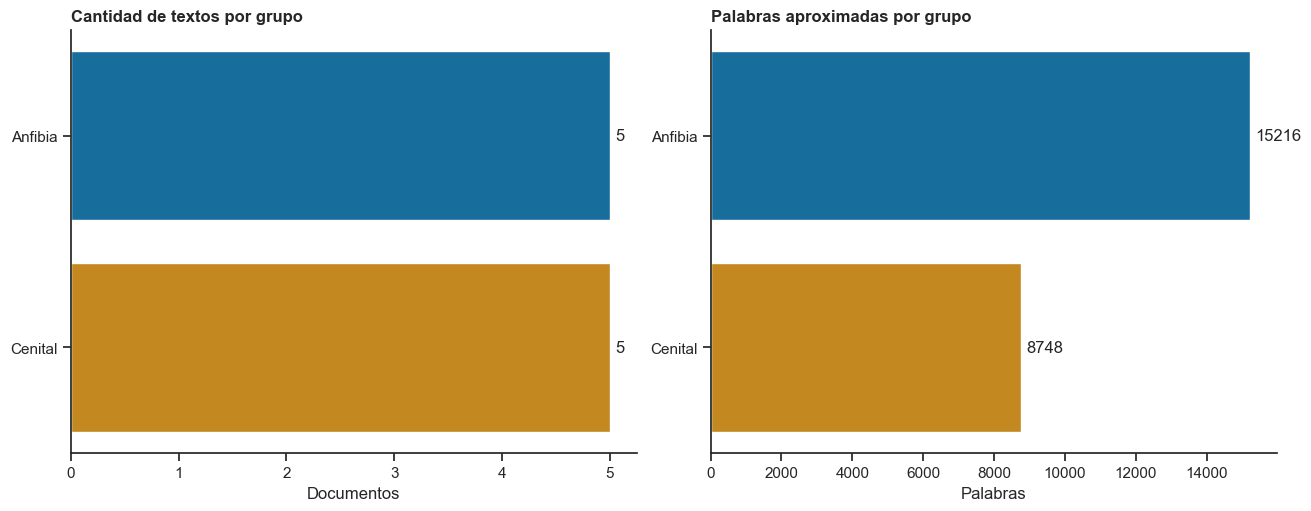

In [6]:
# Gráficos de comparación: cantidad de textos y palabras por grupo.
# Dos paneles en paralelo facilitan la comparación visual del balance del corpus.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# --- Panel izquierdo: cantidad de documentos ---
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,       # Colorea cada barra según el grupo al que pertenece
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)  # Muestra el valor exacto al final de cada barra
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])  # Elimina los bordes superior y derecho para un estilo más limpio

# --- Panel derecho: palabras totales ---
# Si Anfibia tiene muchas más palabras que Cenital, sus frecuencias absolutas serán mayores por extensión, no por énfasis
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()

**Observación del desbalance:**

Los gráficos confirman lo anticipado: ambos grupos tienen la misma cantidad de textos (5 cada uno), pero Anfibia casi **duplica** el total de palabras de Cenital (≈15.200 vs. ≈8.700).

**Consecuencias metodológicas que esto genera:**

1. **Las frecuencias absolutas de Anfibia serán sistemáticamente más altas** simplemente porque hay más texto, no necesariamente porque ese tema sea más central para ese medio. Cualquier comparación del tipo "Anfibia usa X más que Cenital" debe ajustarse por el factor de escala antes de sacar conclusiones.

2. **TF-IDF mitiga el problema** al trabajar con pesos relativos que normalizan por la extensión de cada "documento" (grupo). La lectura de TF-IDF será más confiable que la de BoW para detectar términos genuinamente distintivos de cada serie.

3. **Los bigramas también se ven afectados**: hay que comparar proporciones o elegir los mismos top N por grupo en lugar de comparar valores absolutos entre grupos.

> **Conclusión provisoria:** las diferencias cualitativas de vocabulario (qué términos aparecen) importan más que las diferencias cuantitativas de frecuencia (cuántas veces aparecen), dado el desbalance de extensión.

**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [7]:
# Cargamos el modelo lingüístico de spaCy en español.
# es_core_news_sm incluye: tokenizador, lematizador, etiquetador gramatical (POS) y reconocedor de entidades (NER).
# Si el modelo no está instalado, el bloque except muestra el comando para instalarlo.
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)  # Carga el modelo indicado en los parámetros de configuración
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error

Modelo cargado correctamente: es_core_news_sm


In [8]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico '-pron-', usa la forma original del token."""
    lema = token.lemma_.strip().lower()   # token.lemma_ devuelve la forma base (ej: "corriendo" → "correr")
    if not lema or lema == "-pron-":      # "-pron-" es el lema genérico de pronombres en algunos modelos spaCy
        lema = token.text.lower()         # Fallback: usamos la forma original del token si el lema no es útil
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []

# nlp.pipe() procesa todos los textos en lotes (batch_size=8).
# Es más eficiente que llamar nlp(texto) en un bucle porque aprovecha la vectorización interna del modelo.
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []      # Todos los lemas del documento (incluyendo stopwords y signos)
    contenido = []  # Solo palabras con contenido semántico (sin stopwords, sin signos)
    entidades = []  # Lista de entidades nombradas detectadas (personas, organizaciones, lugares)

    for token in doc:
        if token.is_space:  # Saltamos tokens que son solo espacios en blanco (saltos de línea, tabulaciones)
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)

        # Filtramos palabras de contenido: deben cumplir DOS condiciones:
        # 1. is_alpha: el token contiene solo letras (sin números ni signos de puntuación)
        # 2. not is_stop: no es una stopword (artículo, preposición, conjunción, etc.)
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos las entidades nombradas del documento completo.
    # Cada entidad tiene: .text (texto original) y .label_ (tipo: PER, ORG, LOC, MISC)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),          # String con todos los lemas del documento
        "texto_contenido": " ".join(contenido),  # String con solo las palabras de contenido
        "entidades": entidades,                   # Lista de dicts con cada entidad detectada
    })

# Unimos los nuevos campos al DataFrame principal usando pd.concat en el eje de columnas (axis=1)
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())

,titulo,grupo_comparacion,texto_contenido
0,La burbuja de la inteligencia artificial,Cenital,inteligencia artificial corresponder beneficio prometer estallar burbuja especulativo proyectar empresa estadounidense mil millón inteli...
1,"La inteligencia artificial no muestra el pasado, lo reescribe",Cenital,procesar archivo colorearla animarlos realidad peligroso trivial febrero openai sociedad sora generador video buscar deslumbrar ejemplo ...
2,Una nueva vida no biolÃ³gica: Â¿quÃ© tan gobernados estamos por la inteligencia artificial?,Cenital,desarrollar inteligencia superar estã decantar forma vida justo hacer momento noticia llamir minuto comienzo inteligencia artificial apa...
3,"La nueva fase de la competencia tecnolÃ³gica: chips, datos y poder",Cenital,disputa unidos china control inteligencia artificial ingrés etapa estructural disputa unidos china control inteligencia artificial estã ...
4,La inteligencia artificial no previene la estupidez natural,Cenital,definir disciplina quã relacionar él colonialismo holis acã contemplar hoja excel llamado compruebo tiempo forma cosa resultar sumamente...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [9]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        # Unimos todos los textos de contenido del grupo en un solo string y contamos frecuencias con Counter.
        # Counter es equivalente a un diccionario donde la clave es el término y el valor es su frecuencia.
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):  # most_common(n) devuelve los n términos más frecuentes
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


# Obtenemos y mostramos los términos más frecuentes por grupo
top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)

,grupo,término,frecuencia
0,Anfibia,sistema,154
1,Anfibia,ia,121
2,Anfibia,dato,101
3,Anfibia,and,41
4,Anfibia,desarrollo,40
5,Anfibia,modelo,39
6,Anfibia,s,37
7,Anfibia,artificial,36
8,Anfibia,él,36
9,Anfibia,inteligencia,34


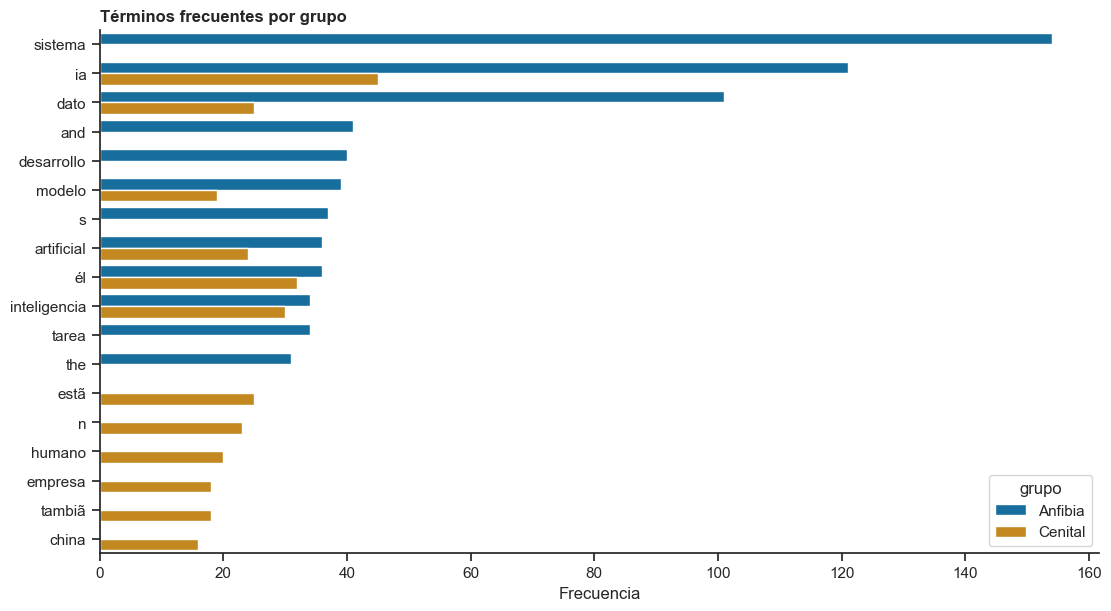

In [10]:
# Gráfico de barras horizontal: comparación de términos frecuentes entre grupos.
# hue="grupo" colorea cada barra según el grupo, lo que permite ver diferencias en un solo gráfico.
# El eje vertical (y) muestra los términos; el horizontal (x) muestra la frecuencia de aparición.
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",   # Eje horizontal: cuántas veces aparece el término
    y="término",      # Eje vertical: palabras más frecuentes (una por fila)
    hue="grupo",      # Color diferenciado por grupo (Cenital vs Anfibia)
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()

In [11]:
# --- Entidades nombradas por grupo ---
# Cada fila del corpus puede contener varias entidades. Las expandimos en registros individuales
# para poder contarlas, filtrarlas y comparar su distribución entre grupos.
registros_entidades = []
for fila in df.itertuples(index=False):  # itertuples es más eficiente que iterrows para DataFrames
    for entidad in fila.entidades:       # Iteramos sobre la lista de entidades de cada texto
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),   # Obtenemos el grupo de la fila por nombre de atributo
            "texto_entidad": entidad["texto"],        # Texto exacto de la entidad detectada (ej: "OpenAI", "China")
            "etiqueta": entidad["etiqueta"],          # Tipo de entidad: PER (persona), ORG (organización), LOC (lugar), MISC
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por las tres columnas para contar cuántas veces aparece cada entidad en cada grupo
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()                              # Cuenta las ocurrencias de cada combinación
        .reset_index(name="frecuencia")      # Convierte el resultado en una columna llamada "frecuencia"
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])  # Ordena: por grupo (A-Z) y frecuencia (mayor a menor)
    )
    display(top_entidades.head(TOP_N * 2))  # Mostramos el doble de TOP_N para ver representantes de ambos grupos
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")

,grupo,texto_entidad,etiqueta,frecuencia
257,Anfibia,IA,LOC,77
702,Anfibia,©,LOC,26
339,Anfibia,LatamGPT,MISC,15
80,Anfibia,Cenia,LOC,12
274,Anfibia,Inteligencia Artificial,MISC,12
704,Anfibia,©,PER,12
236,Anfibia,Google,ORG,10
668,Anfibia,mÃ¡quina,LOC,10
645,Anfibia,estÃ,ORG,9
507,Anfibia,Soto,PER,7


**Lectura de los observables:**

El análisis de términos, entidades y bigramas muestra una diferencia que supera el desbalance de extensión:

**Términos compartidos — lo que no diferencia a los grupos:**

Tanto Cenital como Anfibia tienen entre sus términos más frecuentes "ia", "inteligencia", "artificial", "sistema" y "dato". Son el vocabulario nuclear del tema. Su alta frecuencia en ambos grupos confirma que el corpus es temáticamente coherente, pero no dice nada sobre el posicionamiento editorial de cada medio.

**Términos que sí diferencian — primera señal de contraste:**

| Cenital | Anfibia |
|---|---|
| china, empresa, humano | sistema, tarea, desarrollo, exactitud |
| sam altman, openai, nvidia | latamgpt, cenia, chatgpt |
| Encuadre: geopolítico y económico | Encuadre: técnico-crítico y regional |

**Bigramas — cómo se organizan los discursos:**

El bigrama dominante de Anfibia es "sistema ia" (34 ocurrencias), que remite a arquitectura y diseño de sistemas. El de Cenital es "inteligencia artificial" (22) seguido de "mil millón" (9) y "sam altman" (3), que remite a economía y actores de la industria global.

**Entidades — quién protagoniza cada serie:**

Cenital nombra corporaciones y estados como protagonistas de una disputa (China, OpenAI, Nvidia, Facebook). Anfibia nombra herramientas y proyectos regionales latinoamericanos (LatamGPT, Cenia, ChatGPT, Google). Estos patrones orientan la interpretación, pero antes de afirmar que Cenital tiene un enfoque geopolítico y Anfibia uno técnico-regional, hay que volver a los fragmentos para verificar cómo se usan esos términos en contexto real.

In [12]:
# --- Bigramas por grupo ---
# Un bigrama es una secuencia de dos palabras consecutivas (ej: "inteligencia artificial").
# Son más informativos que las palabras individuales porque capturan asociaciones habituales.

# ngram_range=(2,2) le dice al vectorizador que use solo bigramas (no unigramas ni trigramas)
# lowercase=False preserva mayúsculas para no perder distinción en nombres propios del texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos la matriz sparse (eficiente en memoria) a un DataFrame denso con:
# - filas: cada texto del corpus (indexado por título)
# - columnas: cada bigrama posible del vocabulario
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos las frecuencias de bigramas dentro de cada grupo.
# .assign(grupo=...) agrega la columna de grupo temporalmente para el groupby.
# .T transpone la tabla: los bigramas quedan como filas y los grupos como columnas.
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()   # Suma las frecuencias de cada bigrama en todos los textos del grupo
    .T       # Transposición: ahora podemos ordenar cada grupo de forma independiente
)

# Extraemos los top_n bigramas de cada grupo ordenados por frecuencia descendente
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)

,grupo,bigrama,frecuencia
0,Anfibia,sistema ia,34
1,Anfibia,inteligencia artificial,29
2,Anfibia,sistema inteligente,17
3,Anfibia,crear sistema,13
4,Anfibia,of the,12
5,Anfibia,the acm,10
6,Anfibia,gã nero,10
7,Anfibia,base dato,9
8,Anfibia,campo ia,9
9,Anfibia,conference on,9


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [13]:
# Para calcular BoW y TF-IDF comparando grupos, tratamos cada grupo como un único "documento".
# Concatenamos todos los textos de contenido de un grupo en un solo string con " ".join.
# Esto es necesario porque CountVectorizer y TfidfVectorizer trabajan sobre una lista de documentos.
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)          # Agrupamos sin convertir el grupo en índice
    .agg(texto_modelo=("texto_contenido", " ".join))   # Unimos todos los textos del grupo en uno solo
    .rename(columns={COLUMNA_GRUPO: "grupo"})          # Renombramos para mayor claridad
)

display(corpus_por_grupo)

,grupo,texto_modelo
0,Anfibia,inteligencia artificial allã big tech noventa ciento principal lenguaje aplicación ia provenir norte funcionar sur global estã gestar mo...
1,Cenital,inteligencia artificial corresponder beneficio prometer estallar burbuja especulativo proyectar empresa estadounidense mil millón inteli...


**BoW vs. TF-IDF: volumen versus especificidad**

**Lo que BoW muestra:**

Con Bag of Words, los primeros puestos en Anfibia son términos en inglés ("and", "the", "in"), artefacto de referencias bibliográficas académicas incluidas en al menos un artículo. Los términos compartidos más frecuentes —"sistema", "dato", "desarrollo", "modelo"— aparecen en ambos grupos con valores similares (ajustando por extensión). BoW no distingue entre "este término es importante para este grupo" y "este término aparece más porque el texto es más largo".

**Lo que TF-IDF revela:**

TF-IDF cambia radicalmente la imagen al penalizar los términos compartidos y premiar los exclusivos:

| Cenital — más distintivos | Peso TF-IDF | Anfibia — más distintivos | Peso TF-IDF |
|---|---|---|---|
| china | 0.3141 | latamgpt | 0.1484 |
| chip | 0.1767 | exactitud | 0.1391 |
| nvidia | 0.1767 | colección | 0.1391 |
| trump | 0.0982 | cenia | 0.1206 |
| estadounidense | 0.0982 | acceso | 0.1020 |

**La diferencia central:**

> BoW dice: *Anfibia habla más de "sistema".*
> TF-IDF dice: *lo que verdaderamente define a Anfibia es hablar de **qué sistemas**, desde **dónde** y con **qué métricas de evaluación**. Lo que define a Cenital es enmarcar la IA como objeto de competencia entre Estados y empresas.*

**Nota sobre el artefacto metodológico:**

Los términos en inglés con alto peso TF-IDF en Anfibia ("and", "the", "in") no representan el discurso periodístico del medio: son el resultado de referencias bibliográficas en inglés (citas de papers de la ACM) incluidas en al menos un artículo. BoW y TF-IDF no distinguen entre la voz del autor y las citas que incluye.

In [14]:
# --- Funciones auxiliares para convertir matrices en DataFrames legibles ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse de sklearn en un DataFrame de pandas.
    Los vectorizadores devuelven matrices sparse (formato comprimido eficiente en memoria).
    .toarray() las convierte a arrays densos que pandas puede manejar."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila de la tabla), extrae los top_n términos con mayor valor.
    Funciona tanto para frecuencias (BoW) como para pesos (TF-IDF)."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():  # Iteramos fila por fila (una por grupo)
        # Filtramos términos con valor mayor a 0 (presentes en este grupo) y ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),  # Redondeamos a 4 decimales para legibilidad
            })
    return pd.DataFrame(registros)


# --- Bag of Words (BoW) ---
# CountVectorizer cuenta cuántas veces aparece cada término en cada documento.
# Con solo 2 "documentos" (uno por grupo), max_df=0.95 descarta términos presentes en ambos grupos
# (es decir, términos compartidos que no ayudan a diferenciarlos).
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF (Term Frequency - Inverse Document Frequency) ---
# TF-IDF combina dos medidas:
#   TF (Term Frequency): frecuencia del término dentro del documento (grupo)
#   IDF (Inverse Document Frequency): rareza del término en el corpus total
# Un término con alto TF-IDF aparece mucho en un grupo y poco o nada en el otro → es discriminativo.
# A diferencia de BoW, TF-IDF no es sensible al desbalance de extensión porque normaliza por grupo.
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas para comparar directamente ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)

Top de términos según Bag of Words


,grupo,término,frecuencia
0,Anfibia,and,41.0
1,Anfibia,the,31.0
2,Anfibia,in,20.0
3,Anfibia,latamgpt,16.0
4,Anfibia,deep,15.0
5,Anfibia,exactitud,15.0
6,Anfibia,colección,15.0
7,Anfibia,acm,14.0
8,Anfibia,cenia,13.0
9,Anfibia,on,13.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,Anfibia,and,0.3802
1,Anfibia,the,0.2875
2,Anfibia,in,0.1855
3,Anfibia,latamgpt,0.1484
4,Anfibia,deep,0.1391
5,Anfibia,exactitud,0.1391
6,Anfibia,colección,0.1391
7,Anfibia,acm,0.1298
8,Anfibia,cenia,0.1206
9,Anfibia,on,0.1206


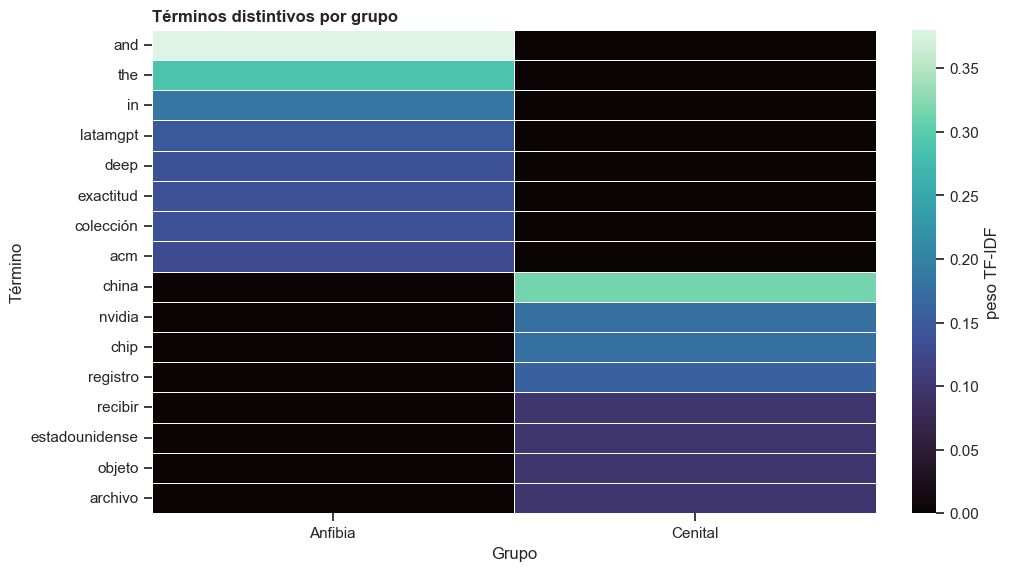

In [15]:
# Mapa de calor (heatmap) de los términos más distintivos según TF-IDF.
# Permite ver de un vistazo qué términos caracterizan a cada grupo: colores más intensos = mayor peso TF-IDF.
# Es más informativo que el gráfico de barras porque muestra la exclusividad de cada término por grupo.

# Seleccionamos los top-8 términos TF-IDF de cada grupo sin repetir.
# dict.fromkeys() elimina duplicados preservando el orden de inserción (más predecible que un set).
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))

# Extraemos solo las columnas de los términos seleccionados y transponemos:
# - antes de .T: filas=grupos, columnas=términos
# - después de .T: filas=términos, columnas=grupos (mejor para el heatmap)
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),  # Altura dinámica: más términos → gráfico más alto
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",           # Paleta secuencial oscuro→claro: más intenso = mayor peso TF-IDF
    linewidths=0.4,        # Líneas finas entre celdas para facilitar la lectura individual
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},  # Etiqueta de la barra de color lateral
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()

**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


### 1. Recorte y comparación

Comparamos el tratamiento discursivo de la inteligencia artificial en dos medios digitales argentinos con perfiles editoriales diferenciados: *Cenital* (periodismo de datos, análisis de coyuntura tecnológica-política) y *Anfibia* (periodismo narrativo, ensayo cultural-académico). El corpus incluye 5 artículos de cada medio sobre IA publicados en el período 2021–2025.

Lo que los vuelve **comparables** es la coincidencia en universo temático, formato y período. Lo que los vuelve **contrastables** es la diferencia de posición editorial: Cenital encuadra la IA desde la geopolítica tecnológica y la economía; Anfibia la encuadra desde la política tecnológica latinoamericana y el análisis técnico-crítico. Esta diferencia de marco no se asume: es lo que el análisis debía confirmar o refutar con datos.

### 2. Lectura distante

*Cenital* se organiza alrededor de actores e instituciones de poder: China (15 menciones en entidades), EE.UU., Nvidia, OpenAI, Sam Altman, Facebook. Los bigramas refuerzan el encuadre económico: "mil millón" (9), "red social" (5), "sam altman" (3). El vocabulario es el del periodismo tecnológico-financiero de coyuntura internacional.

*Anfibia* se organiza alrededor de conceptos técnicos y proyectos regionales: el bigrama dominante es "sistema ia" (34 ocurrencias), seguido de "sistema inteligente" (17), "crear sistema" (13) y "base dato" (9). Las entidades nombradas son herramientas y organizaciones latinoamericanas: LatamGPT (15), Cenia (12), ChatGPT (6). El vocabulario combina técnica de sistemas con preocupaciones de acceso y soberanía regional.

**¿Qué diferencias aparecen con TF-IDF que no aparecen con frecuencias?**

Con BoW, ambos grupos comparten el podio de términos más frecuentes: "ia", "inteligencia", "sistema", "dato". La diferencia visible es solo de cantidad, no de naturaleza. Con TF-IDF el contraste es nítido: los términos diagnósticos de Cenital son geopolíticos (china, chip, nvidia, trump, elección); los de Anfibia son técnico-regionales (latamgpt, exactitud, colección, cenia, acceso).

La diferencia más importante que TF-IDF hace visible: *Cenital habla de **quién tiene el poder** sobre la IA*, mientras que *Anfibia habla de **cómo funciona** la IA y **quién debería poder acceder** a ella desde América Latina*.

### 3. Lectura cercana

**Fragmento 1 — "china" en Cenital (C-4, Federico Merke)**

> *"La disputa entre Estados Unidos y China por el control de la inteligencia artificial ingresa en una etapa de reconfiguración estructural..."*

La palabra no funciona como referencia geográfica neutral sino como uno de los dos polos de una guerra de posición tecnológica. El artículo no describe China desde adentro sino como amenaza o competidor desde la mirada estadounidense. El encuadre geopolítico organiza toda la pieza, y el texto no cuestiona ese encuadre: lo reproduce.

**Fragmento 2 — "latamgpt" en Anfibia (C-6, Ernesto Picco)**

> *"...Hay inteligencia artificial más allá de las big tech. Mientras el noventa por ciento de la información en internet está en inglés, el Cenia trabaja en LatamGPT..."*

El término ancla toda la argumentación del artículo: la soberanía tecnológica requiere datos propios, modelos propios y financiamiento público. La presencia de "latamgpt" como término con alto TF-IDF no es solo un dato de frecuencia —es el nombre del argumento central del grupo. Volver al fragmento muestra que el texto construye una alternativa política, no solo técnica.

**Fragmento 3 — "chip" en Cenital (C-4, Federico Merke)**

> *"...EE.UU. restringió las exportaciones de chips de alta gama a China. Nvidia, el principal fabricante de procesadores para IA..."*

Volver al fragmento muestra que el artículo construye la IA como **problema de cadena de suministro de hardware**, no como problema de algoritmos ni de datos. Esta lectura es imposible de hacer solo mirando la tabla de bigramas; requiere el regreso al texto para entender qué está en juego para el autor.

### 4. Visualización y método

**¿Qué gráfico fue el más útil?**

El heatmap de TF-IDF fue el más útil. A diferencia del gráfico de barras de frecuencias —que solo confirmaba el desbalance de extensión—, el heatmap mostró que los grupos se separan en dimensiones cualitativas: Cenital tiene intensidad alta en términos geopolíticos; Anfibia en términos técnico-regionales. La separación visual entre columnas es la representación más directa del hallazgo central.

**Límites del enfoque:**

1. **No captura sintaxis ni argumento.** Que "china" aparezca 15 veces no dice si el texto critica, celebra o describe a China. La posición discursiva requiere lectura cercana para determinarse.
2. **No distingue citas de voz propia.** El alto peso TF-IDF de términos en inglés en Anfibia revela referencias bibliográficas académicas, no discurso periodístico. BoW y TF-IDF no separan la voz del autor de las fuentes que cita.
3. **El desbalance de extensión contamina el BoW.** Con textos de longitud tan diferente entre grupos, las comparaciones de frecuencias absolutas son poco confiables sin normalización previa.
4. **El corpus pequeño limita la generalización.** 10 textos no permiten afirmar tendencias robustas. Los resultados son descriptivos de esta muestra y no deben extrapolarse como caracterización completa de cada publicación.

**¿Qué no se puede afirmar solo con representaciones sparse?**

No se puede afirmar que un medio "tiene una posición crítica" o "defiende a las big tech" mirando solo frecuencias. Tampoco se puede inferir intención editorial ni efecto sobre el lector. No se detectan ironías, negaciones ni variaciones de sentido de un mismo término en distintos contextos. Las representaciones sparse son un primer filtro que orienta la lectura: su función es señalar hacia dónde mirar, no reemplazar la lectura que confirma o complejiza lo que muestran los números.

## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [16]:
# Seleccionamos los 2 términos con mayor peso TF-IDF de cada grupo.
# Estos son los términos más diagnósticos de cada serie: aparecen mucho en un grupo y casi nada en el otro.
# Son los candidatos ideales para la lectura cercana: volver al texto para ver cómo se usan en contexto real.
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)

,grupo,término,tfidf
0,Anfibia,and,0.3802
1,Anfibia,the,0.2875
2,Cenital,china,0.3141
3,Cenital,nvidia,0.1767


In [17]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve fragmentos con contexto.
    Trabaja sobre el texto original (sin lematizar) para preservar el lenguaje real del autor."""
    # re.compile prepara el patrón para buscarlo eficientemente en múltiples textos
    # \b es un límite de palabra: asegura que "chip" no encuentre "microchip"
    # re.escape convierte caracteres especiales en literales (ej: "c++" → "c\+\+")
    # re.IGNORECASE busca sin distinguir mayúsculas de minúsculas
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]  # Solo textos del grupo indicado

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)       # Texto original del artículo
        coincidencia = patron.search(texto)        # Busca la primera aparición del término
        if not coincidencia:
            continue  # Si el término no aparece en este texto, pasamos al siguiente

        # Calculamos los límites de la ventana de contexto alrededor del término encontrado
        # max(0, ...) evita índices negativos cuando el término está al inicio del texto
        # min(len(texto), ...) evita superar el final del texto
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Señalizamos con "..." si el fragmento fue recortado respecto al texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:  # Limitamos la cantidad de fragmentos por término
            break
    return registros


# --- Extraemos fragmentos para cada uno de los términos más distintivos ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,   # Buscamos en el texto original (no en el procesado/lematizado)
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

,grupo,término,título,fragmento
0,Anfibia,and,"Inteligencia artificial, pero Â¿a quÃ© costo?","...estrategias conjuntas que nos permitan caminar hacia ellos.\n[1] Ahmed, N., & Wahed, M. (2020). The de-democratization of ai: Deep le..."
1,Anfibia,and,Â¿QuiÃ©n controla los sistemas de Inteligencia Artificial?,"...orma de garantizar que dichos sistemas actÃºen para el beneficio de la sociedad.\nReferencias:\n\n[1] K. Cho, B. van Merrienboer, D. ..."
2,Anfibia,the,"Inteligencia artificial, pero Â¿a quÃ© costo?","...uirlos dependerÃ¡ nuestra capacidad de crear estrategias conjuntas que nos permitan caminar hacia ellos.\n[1] Ahmed, N., & Wahed, M. ..."
3,Anfibia,the,Â¿QuiÃ©n controla los sistemas de Inteligencia Artificial?,"...e dichos sistemas actÃºen para el beneficio de la sociedad.\nReferencias:\n\n[1] K. Cho, B. van Merrienboer, D. Bahdanau, and Y. Beng..."
4,Cenital,china,La burbuja de la inteligencia artificial,"...up clave que se queda sin fondos, una caÃ­da en la demanda de chips o incluso un movimiento geopolÃ­tico, como una eventual restricci..."
5,Cenital,china,Una nueva vida no biolÃ³gica: Â¿quÃ© tan gobernados estamos por la inteligencia artificial?,...er invento masivo donde se cruzÃ³ el afÃ¡n totalitario de controlar a la poblaciÃ³n con la IA es el modelado de puntuaciones ciudadan...
6,Cenital,china,"La nueva fase de la competencia tecnolÃ³gica: chips, datos y poder",La disputa entre Estados Unidos y China por el control de la inteligencia artificial ingresa en una etapa de reconfiguraciÃ³n estructura...
7,Cenital,nvidia,La burbuja de la inteligencia artificial,"...tal relacionados con la IA, frente a unos 35 mil millones de ganancias. La Ãºnica empresa que verdaderamente estÃ¡ haciendo un negoci..."
8,Cenital,nvidia,"La nueva fase de la competencia tecnolÃ³gica: chips, datos y poder","...e todos los nuevos centros de datos financiados con fondos pÃºblicos usen exclusivamente chips de IA producidos en China, excluyendo ..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


### Respuestas complementarias finales a las preguntas de la sección 10

Esta celda deja explícita la verificación final de las preguntas planteadas en el trabajo. No reemplaza el análisis anterior: lo ordena como cierre y agrega los comentarios metodológicos necesarios para que el recorrido sea más fácil de evaluar.

#### 1. Recorte y comparación

**¿Qué se compara exactamente?**

Se compara el tratamiento discursivo de la inteligencia artificial en dos grupos de textos periodísticos: cinco artículos de *Cenital* y cinco artículos de *Anfibia*. La variable de comparación es el medio, registrada en la columna `grupo_comparacion`. En ambos casos la IA aparece como tema central, no como mención lateral, por eso el corpus cumple con la condición de consistencia temática.

**¿Qué vuelve válidos esos dos grupos como contraste?**

Los grupos son válidos porque tienen igual cantidad de documentos, comparten idioma, soporte digital, período aproximado y género discursivo amplio (artículos de análisis/opinión). La diferencia que se busca observar no es temática sino de encuadre: *Cenital* tiende a organizar la IA como problema de poder tecnológico, mercado, empresas y geopolítica; *Anfibia* tiende a organizarla como problema técnico, cultural, latinoamericano y de acceso.

#### 2. Lectura distante

**¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?**

En *Cenital* se destacan términos y entidades vinculados con actores de poder y competencia tecnol?gica: `china`, `nvidia`, `chip`, `openai`, `sam altman`, `empresa`, `mil mill?n`. Los bigramas `mil millón`, `red social`, `centro dato` y `sam altman` refuerzan un marco económico-industrial.

En *Anfibia* se destacan `sistema`, `dato`, `latamgpt`, `cenia`, `exactitud`, `colección`, `acceso` y asociaciones como `sistema ia`, `sistema inteligente`, `crear sistema` y `base dato`. Ese vocabulario orienta la lectura hacia infraestructura de datos, evaluación de sistemas, soberanía tecnológica regional y condiciones de acceso.

**¿Qué diferencias aparecen con más claridad en TF-IDF y no solo en frecuencias?**

Las frecuencias muestran el vocabulario común de la temática: `ia`, `inteligencia`, `artificial`, `sistema`, `dato`. TF-IDF permite distinguir los términos, más diagnósticos de cada serie. En *Cenital*, `china`, `chip` y `nvidia` apuntan a geopolítica y hardware estratégico. En *Anfibia*, `latamgpt`, `cenia`, `exactitud`, `colecci?n` y `acceso` apuntan a proyectos regionales, datasets y criterios técnicos de evaluación. Por eso TF-IDF resulta más útil que BoW para el contraste central.

#### 3. Lectura cercana

**¿Cómo aparece en contexto al menos un término distintivo de cada grupo?**

En *Cenital*, `china` y `chip` no aparecen como palabras sueltas sino dentro de un relato de competencia entre Estados Unidos, China y empresas tecnológicas. La IA queda asociada a cadenas de suministro, restricciones de exportación, centros de datos, inversión y control de infraestructura.

En *Anfibia*, `latamgpt` aparece como nombre de un proyecto regional que permite discutir dependencia tecnológica, disponibilidad de datos en español y portugués, financiamiento público y soberanía digital. El término funciona como condensador de una pregunta política: quién construye la IA, con qué datos y para qué comunidad linguística.

**¿Qué cambia cuando se vuelve al fragmento?**

La vuelta al fragmento evita leer los términos como etiquetas aisladas. `china` no significa simplemente "país mencionado": en el corpus de *Cenital* funciona como polo de una disputa estratégica. `latamgpt` no significa solo "herramienta nombrada": en *Anfibia* organiza una posición sobre autonomía tecnológica latinoamericana. La lectura cercana confirma que las diferencias estadísticas tienen sentido discursivo.

#### 4. Visualización y método

**¿Qué gráfico ayuda realmente a comprender mejor el contraste?**

El heatmap de TF-IDF fue el gráfico más útil porque muestra simultáneamente la intensidad de los términos distintivos y su distribución por grupo. El gráfico de barras de palabras totales fue importante como auditoría del desbalance; el gráfico de términos frecuentes ayudá a ver recurrencias iniciales; pero el heatmap fue el que mejor condensó la diferencia cualitativa entre vocabulario compartido y vocabulario específico.

**¿Qué límites tiene este enfoque para leer discurso?**

El enfoque tiene cuatro límites principales. Primero, el corpus es pequeño y no permite generalizar sobre la totalidad de cada medio. Segundo, hay desbalance de extensión: *Anfibia* aporta muchas más palabras que *Cenital*, lo que afecta las frecuencias brutas. Tercero, las representaciones sparse no interpretan posición, ironía, negación ni argumento. Cuarto, el corpus conserva problemas de codificación en algunos caracteres (`?`, `?`), lo que puede contaminar lemas, entidades y bigramas; aun así, los términos centrales del contraste se mantienen legibles y el patrón principal sigue siendo interpretable.

**¿Qué no se puede afirmar solo con estas representaciones sparse?**

No se puede afirmar, solo por BoW o TF-IDF, que un medio "defiende" o "rechaza" la IA, ni inferir intención editorial, valoración moral o efecto sobre los lectores. Tampoco se puede separar automáticamente la voz del autor de citas, referencias bibliográficas o ejemplos. Las representaciones sparse sirven como brújula: indican dónde mirar, pero la interpretación discursiva se sostiene recién cuando esos indicios se contrastan con fragmentos concretos.

#### Verificaci?n final de preguntas respondidas

| Pregunta o requisito | Estado | D?nde queda respondido |
|---|:---:|---|
| Justificar corpus y comparaci?n | Respondido | Secciones 4 y 10 + esta celda complementaria |
| Validar estructura, cantidad de textos y dos grupos | Respondido | Secci?n 3 y checklist final |
| Procesar con `spaCy` | Respondido | Secci?n 6, con comentarios sobre lemas, contenido y entidades |
| Construir observables con frecuencias, entidades y bigramas | Respondido | Secci?n 7 |
| Comparar BoW y TF-IDF | Respondido | Secci?n 8 |
| Usar al menos dos visualizaciones anal?ticas | Respondido | Secciones 5, 7 y 8 |
| Volver a tres fragmentos concretos | Respondido | Secciones 9 y 10 |
| Cerrar con interpretaci?n comparativa | Respondido | Secci?n 10 + esta celda complementaria |
| Explicitar l?mites del m?todo | Respondido | Secci?n 10 + apartado de l?mites de esta celda |


In [18]:
# --- Exportación opcional de tablas auxiliares ---
# Permite guardar todos los resultados del análisis como archivos CSV separados.
# Útil para revisar los datos en Excel, archivar resultados o compartirlos fuera del notebook.
# Para activar la exportación, cambiar EXPORTAR_RESULTADOS a True.

EXPORTAR_RESULTADOS = False           # Cambiar a True para activar la exportación
CARPETA_SALIDA = Path("salidas_tpi2") # Carpeta donde se guardarán los archivos (se crea automáticamente)

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)  # Crea la carpeta si no existe; no falla si ya existe (exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")

Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

| Ítem | Estado | Detalle |
|---|:---:|---|
| Corpus con 6–10 textos y exactamente dos grupos comparables | ✅ | 10 textos: 5 Cenital + 5 Anfibia |
| Columna `grupo_comparacion` completa y sin nulos | ✅ | Dos valores exactos: "Cenital" y "Anfibia" |
| Procesamiento con `spaCy` (lematización + entidades nombradas) | ✅ | Sección 6: lemas, texto de contenido y NER por documento |
| Lectura de bigramas | ✅ | Sección 7: top bigramas por grupo con CountVectorizer ngram_range=(2,2) |
| Bag of Words | ✅ | Sección 8: CountVectorizer sobre corpus por grupo |
| TF-IDF con comparación explícita frente a BoW | ✅ | Sección 8: tablas paralelas BoW vs TF-IDF + pausa de lectura |
| Al menos dos visualizaciones analíticas legibles | ✅ | Gráfico de barras doble (sección 5) + barras de términos (sección 7) + heatmap TF-IDF (sección 8) |
| Vuelta a al menos tres fragmentos concretos del corpus | ✅ | Sección 9 (automática) + sección 10 lectura cercana (china, latamgpt, chip) |
| Interpretación comparativa final con evidencia | ✅ | Sección 10: cuatro partes con datos, tablas y fragmentos citados |
| Sección explícita de límites del método | ✅ | Sección 10.4: cuatro límites identificados con justificación |
| Notebook ejecutable de principio a fin sin ediciones manuales | ✅ | El corpus está en la misma carpeta; todas las variables configurables en la sección 2 |